In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
df= pd.read_csv("/content/hey_clientes.csv")

In [ ]:
df.head(5)

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,527,1,app_android,10.0,False,True,es_MX,False,2,False
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,714,3,app_android,8.0,False,True,es_MX,True,2,False
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,...,454,3,app_ios,8.0,False,True,es_MX,False,2,False
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,...,837,16,app_ios,10.0,True,False,es_MX,True,3,False
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,...,533,1,app_ios,7.0,False,True,es_MX,True,2,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15025 entries, 0 to 15024
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  15025 non-null  object 
 1   edad                     15025 non-null  int64  
 2   sexo                     15025 non-null  object 
 3   estado                   14593 non-null  object 
 4   ciudad                   14593 non-null  object 
 5   nivel_educativo          15025 non-null  object 
 6   ocupacion                15025 non-null  object 
 7   ingreso_mensual_mxn      15025 non-null  int64  
 8   antiguedad_dias          15025 non-null  int64  
 9   es_hey_pro               15025 non-null  bool   
 10  nomina_domiciliada       15025 non-null  bool   
 11  canal_apertura           15025 non-null  object 
 12  score_buro               15025 non-null  int64  
 13  dias_desde_ultimo_login  15025 non-null  int64  
 14  preferencia_canal     

In [ ]:
df.isnull().sum()

,0
user_id,0
edad,0
sexo,0
estado,432
ciudad,432
nivel_educativo,0
ocupacion,0
ingreso_mensual_mxn,0
antiguedad_dias,0
es_hey_pro,0


#Valor del cliente

In [ ]:
df['valor_cliente'] = (
    df['ingreso_mensual_mxn'] * 0.4 +
    df['num_productos_activos'] * 1000 +
    df['score_buro'] * 10
)

df[['valor_cliente']].describe()

,valor_cliente
count,15025.000000
mean,20334.798669
std,8794.656096
min,5610.000000
25%,13830.000000
50%,18120.000000
75%,24590.000000
max,52180.000000


#Clustering

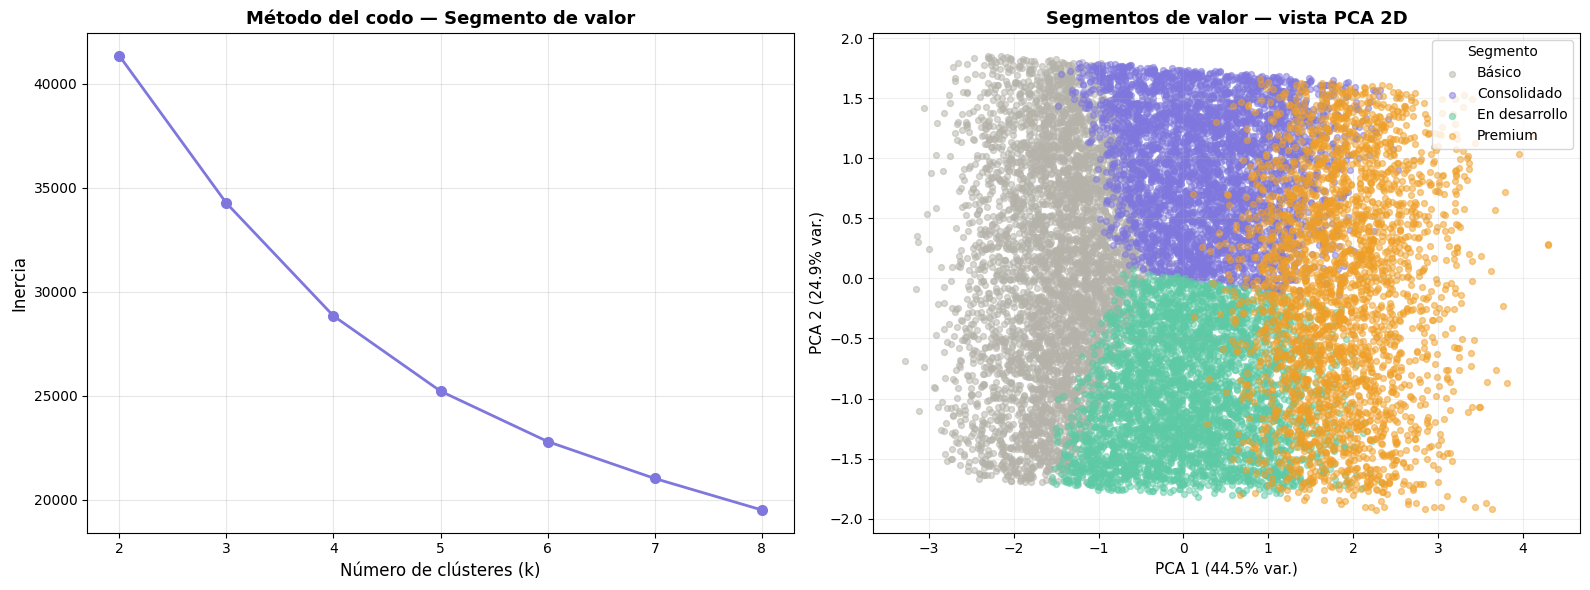


── Perfil promedio por segmento ──
                      ingreso_mensual_mxn  num_productos_activos  score_buro  antiguedad_dias  valor_cliente
segmento_valor_label                                                                                        
Básico                            17568.8                    1.2       478.2            935.3        13010.8
Consolidado                       25370.2                    2.5       670.3           1416.6        19366.0
En desarrollo                     24615.8                    2.4       660.5            439.9        18889.7
Premium                           62649.6                    3.2       708.3            948.1        35322.0

── Distribución de clientes ──
segmento_valor_label
Básico           4407
Consolidado      3934
En desarrollo    3900
Premium          2784
Name: count, dtype: int64


In [ ]:
# ── Features del segmento de valor ──────────────────────────────────────────
features_valor = [
    'ingreso_mensual_mxn',
    'num_productos_activos',
    'score_buro',
    'antiguedad_dias'
]

df_valor = df[features_valor].copy()

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_valor)

# Elegir k óptimo con el método del codo
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica del codo
axes[0].plot(K_range, inertias, 'o-', color='#7F77DD', linewidth=2, markersize=7)
axes[0].set_xlabel('Número de clústeres (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del codo — Segmento de valor', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Modelo final con k=4 (ajusta según el codo)
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['segmento_valor'] = km_final.fit_predict(X_scaled)

# Etiquetar segmentos por valor promedio
medias = df.groupby('segmento_valor')['valor_cliente'].mean().sort_values()
mapa_etiquetas = {
    medias.index[0]: 'Básico',
    medias.index[1]: 'En desarrollo',
    medias.index[2]: 'Consolidado',
    medias.index[3]: 'Premium',
}
df['segmento_valor_label'] = df['segmento_valor'].map(mapa_etiquetas)

# PCA para visualización 2D
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df['pca1'] = coords[:, 0]
df['pca2'] = coords[:, 1]

colores = {'Básico': '#B4B2A9', 'En desarrollo': '#5DCAA5',
           'Consolidado': '#7F77DD', 'Premium': '#EF9F27'}

for label, grupo in df.groupby('segmento_valor_label'):
    axes[1].scatter(grupo['pca1'], grupo['pca2'],
                    c=colores[label], label=label, alpha=0.5, s=18)

axes[1].set_xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)', fontsize=11)
axes[1].set_ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)', fontsize=11)
axes[1].set_title('Segmentos de valor — vista PCA 2D', fontsize=13, fontweight='bold')
axes[1].legend(title='Segmento')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Tabla resumen de cada segmento
print("\n── Perfil promedio por segmento ──")
resumen = df.groupby('segmento_valor_label')[features_valor + ['valor_cliente']].mean().round(1)
print(resumen.to_string())

print("\n── Distribución de clientes ──")
print(df['segmento_valor_label'].value_counts())

#Arquetipo financiero

── Estadísticas por arquetipo ──
              edad_prom  ingreso_prom  score_prom     nivel_edu      ocupacion     n
arquetipo_id                                                                        
0                  36.8       22194.8       595.7  Licenciatura       Empleado  4422
1                  26.2       20072.5       596.1  Preparatoria       Empleado  2883
2                  36.3       21632.6       578.8  Licenciatura  Independiente  2620
3                  46.3       25920.0       618.5  Preparatoria       Empleado  2269
4                  42.4       62220.2       713.5  Licenciatura  Independiente  2831


/tmp/ipykernel_4312/702102918.py:76: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4312/702102918.py:76: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4312/702102918.py:76: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4312/702102918.py:76: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/di

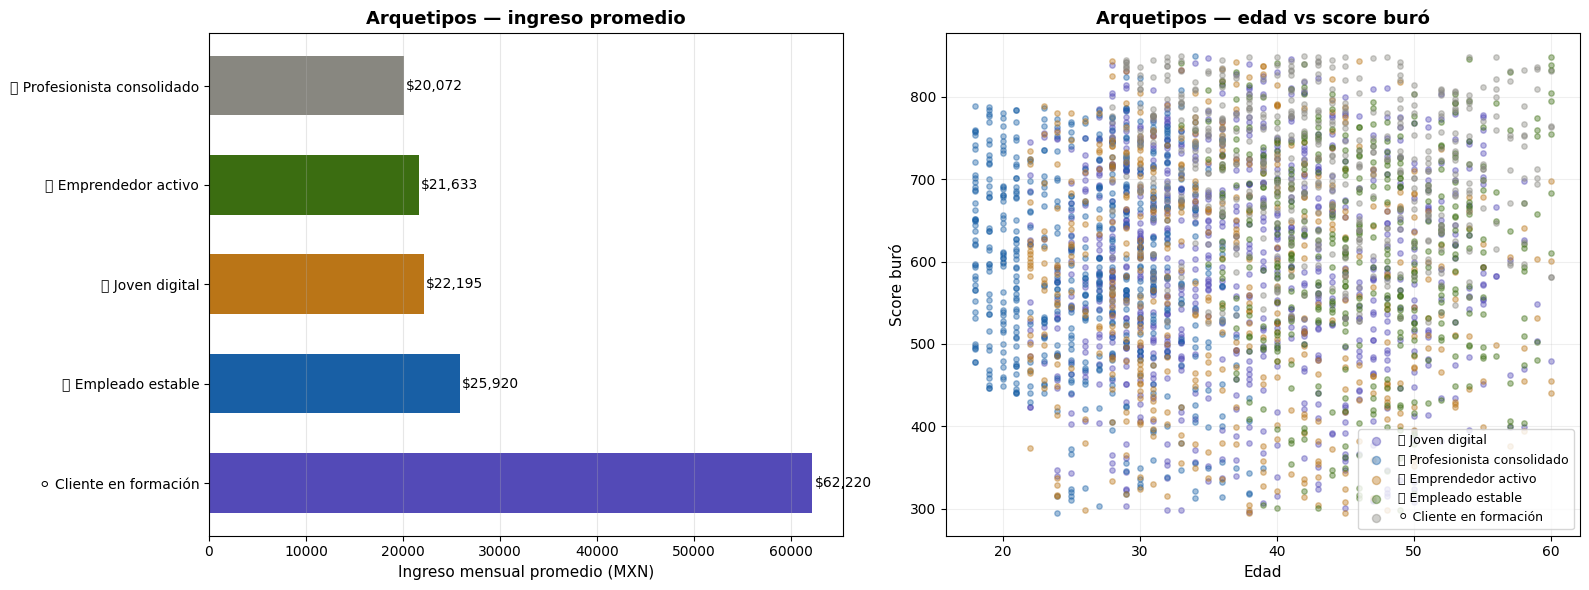


── Guía de tono para el chatbot ──
  🟣 Joven digital: Directo, emojis, enfocado en ahorro y cashback
  🔵 Profesionista consolidado: Formal-amigable, inversiones, seguros
  🟡 Emprendedor activo: Ágil, crédito, flujo de efectivo
  🟢 Empleado estable: Confianza, nómina, metas de largo plazo
  ⚪ Cliente en formación: Educativo, simple, primeros productos


In [ ]:
from sklearn.preprocessing import LabelEncoder

# ── Preparar features mixtas ─────────────────────────────────────────────────
df_arq = df[['edad', 'nivel_educativo', 'ocupacion',
             'ingreso_mensual_mxn', 'score_buro', 'sexo']].copy()

# Encodear categóricas ordinalmente (para clustering)
le = LabelEncoder()
for col in ['nivel_educativo', 'ocupacion', 'sexo']:
    df_arq[col + '_enc'] = le.fit_transform(df_arq[col].astype(str))

features_arq = ['edad', 'ingreso_mensual_mxn', 'score_buro',
                'nivel_educativo_enc', 'ocupacion_enc']

X_arq = StandardScaler().fit_transform(df_arq[features_arq])

km_arq = KMeans(n_clusters=5, random_state=42, n_init=10)
df['arquetipo_id'] = km_arq.fit_predict(X_arq)

# Caracterizar cada arquetipo manualmente con sus promedios
stats_arq = df.groupby('arquetipo_id').agg(
    edad_prom=('edad', 'mean'),
    ingreso_prom=('ingreso_mensual_mxn', 'mean'),
    score_prom=('score_buro', 'mean'),
    nivel_edu=('nivel_educativo', lambda x: x.mode()[0]),
    ocupacion=('ocupacion', lambda x: x.mode()[0]),
    n=('user_id', 'count')
).round(1)

print("── Estadísticas por arquetipo ──")
print(stats_arq.to_string())

# Nombres sugeridos — ajusta según lo que veas en stats_arq
nombres_arq = {
    0: '🟣 Joven digital',
    1: '🔵 Profesionista consolidado',
    2: '🟡 Emprendedor activo',
    3: '🟢 Empleado estable',
    4: '⚪ Cliente en formación',
}
df['arquetipo_label'] = df['arquetipo_id'].map(nombres_arq)

# Visualización: radar chart por arquetipo
from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras de ingreso promedio por arquetipo
orden = stats_arq['ingreso_prom'].sort_values(ascending=False).index
colores_arq = ['#534AB7', '#185FA5', '#BA7517', '#3B6D11', '#888780']
bars = axes[0].barh(
    [nombres_arq[i] for i in orden],
    stats_arq.loc[orden, 'ingreso_prom'],
    color=colores_arq, edgecolor='none', height=0.6
)
axes[0].set_xlabel('Ingreso mensual promedio (MXN)', fontsize=11)
axes[0].set_title('Arquetipos — ingreso promedio', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, stats_arq.loc[orden, 'ingreso_prom']):
    axes[0].text(val + 200, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=10)

# Scatter: edad vs score_buro coloreado por arquetipo
sample = df.sample(min(3000, len(df)), random_state=42)
for i, (label, grupo) in enumerate(sample.groupby('arquetipo_id')):
    axes[1].scatter(grupo['edad'], grupo['score_buro'],
                    c=colores_arq[i], label=nombres_arq[label],
                    alpha=0.4, s=15)

axes[1].set_xlabel('Edad', fontsize=11)
axes[1].set_ylabel('Score buró', fontsize=11)
axes[1].set_title('Arquetipos — edad vs score buró', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, markerscale=1.5)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Tabla para el chatbot: tono recomendado por arquetipo
print("\n── Guía de tono para el chatbot ──")
guia_tono = {
    '🟣 Joven digital':            'Directo, emojis, enfocado en ahorro y cashback',
    '🔵 Profesionista consolidado': 'Formal-amigable, inversiones, seguros',
    '🟡 Emprendedor activo':        'Ágil, crédito, flujo de efectivo',
    '🟢 Empleado estable':          'Confianza, nómina, metas de largo plazo',
    '⚪ Cliente en formación':      'Educativo, simple, primeros productos',
}
for arq, tono in guia_tono.items():
    print(f"  {arq}: {tono}")

#Ecosistema de uso

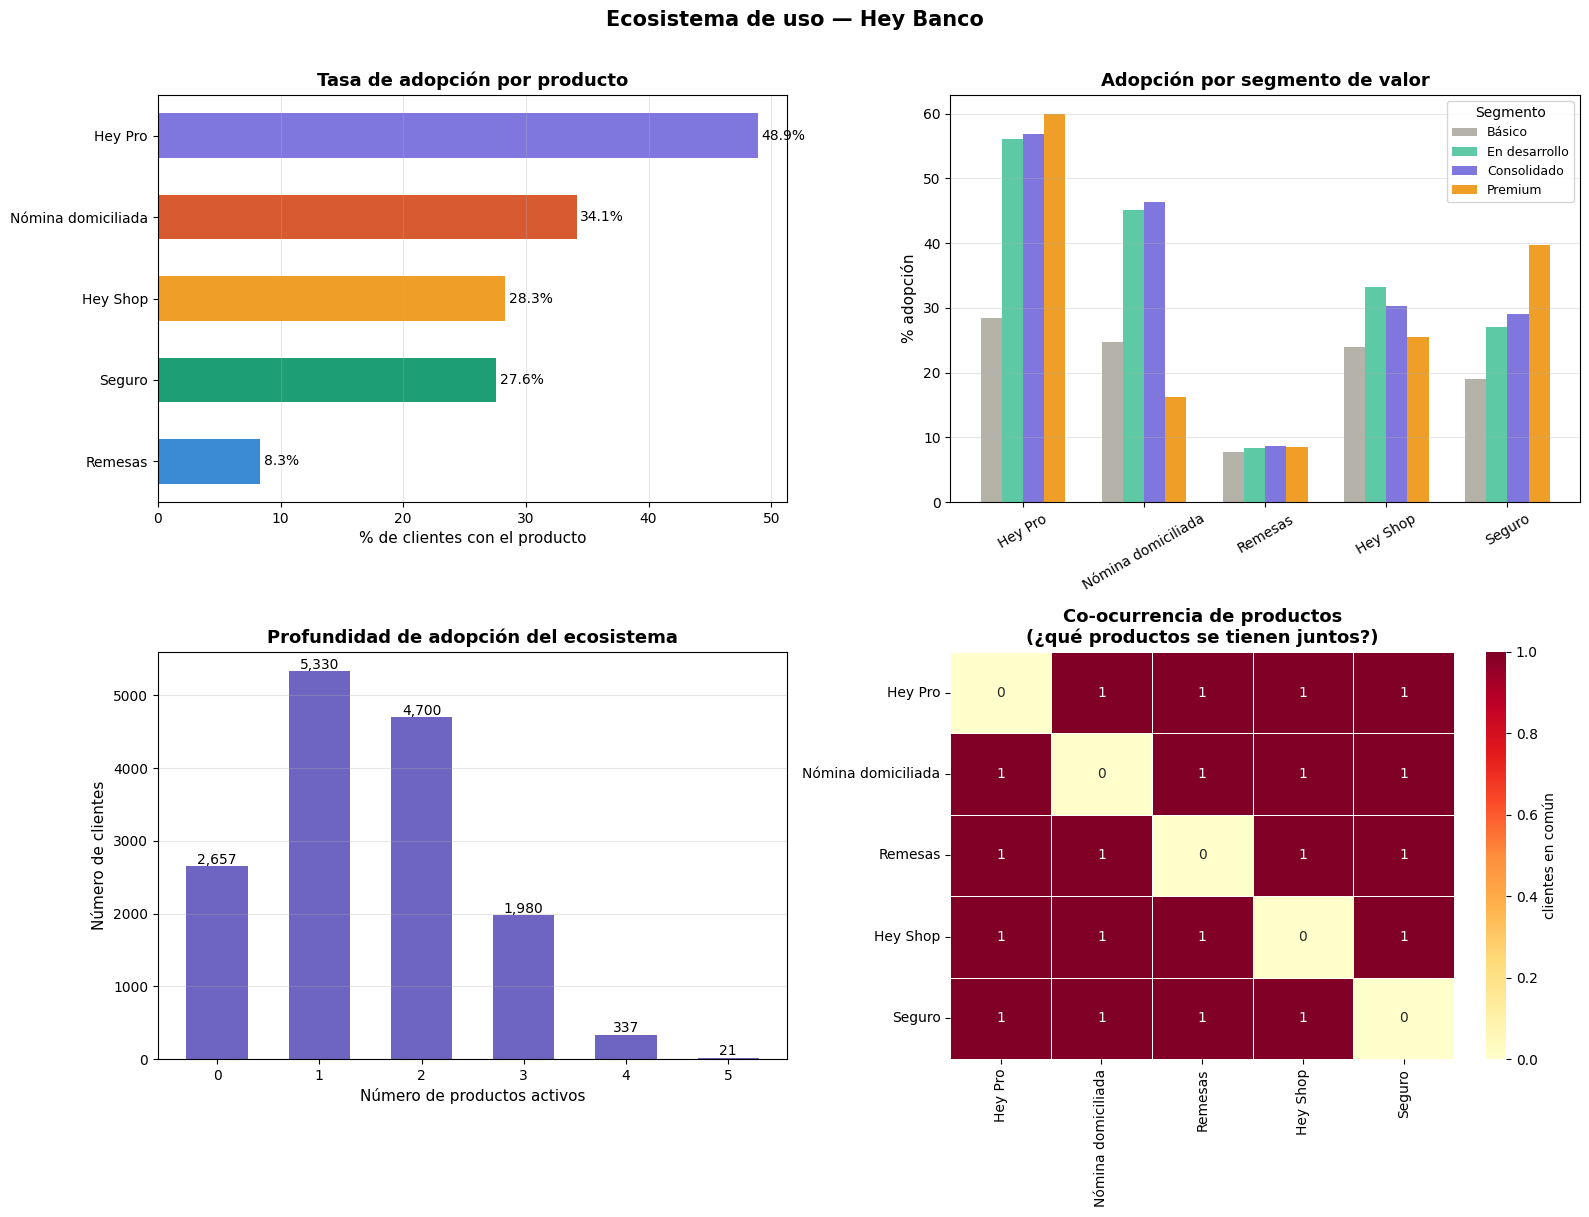


── Oportunidad de cross-sell por segmento ──
  Básico               → siguiente producto sugerido: Remesas (7.8% adopción actual)
  En desarrollo        → siguiente producto sugerido: Remesas (8.4% adopción actual)
  Consolidado          → siguiente producto sugerido: Remesas (8.7% adopción actual)
  Premium              → siguiente producto sugerido: Remesas (8.5% adopción actual)

── Ejemplo de perfil_chatbot ──
0    Segmento: Consolidado | Arquetipo: 🔵 Profesion...
1    Segmento: Consolidado | Arquetipo: 🔵 Profesion...
2    Segmento: Básico | Arquetipo: 🟡 Emprendedor ac...
3    Segmento: Premium | Arquetipo: ⚪ Cliente en fo...
4    Segmento: Básico | Arquetipo: 🔵 Profesionista ...


In [ ]:
# ── Variables de productos/servicios booleanos ───────────────────────────────
productos = ['es_hey_pro', 'nomina_domiciliada', 'recibe_remesas',
             'usa_hey_shop', 'tiene_seguro']

etiquetas = {
    'es_hey_pro':           'Hey Pro',
    'nomina_domiciliada':   'Nómina domiciliada',
    'recibe_remesas':       'Remesas',
    'usa_hey_shop':         'Hey Shop',
    'tiene_seguro':         'Seguro',
}

df_eco = df[productos + ['segmento_valor_label', 'arquetipo_label',
                          'ingreso_mensual_mxn', 'user_id']].copy()

# Profundidad de adopción (cuántos productos tiene)
df['n_productos_bool'] = df[productos].sum(axis=1)
df_eco['n_productos_bool'] = df['n_productos_bool']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# — Gráfica 1: Tasa de adopción general por producto —
tasas = df[productos].mean().sort_values(ascending=True)
colores_prod = ['#3B8BD4', '#1D9E75', '#EF9F27', '#D85A30', '#7F77DD']
bars = axes[0, 0].barh(
    [etiquetas[p] for p in tasas.index],
    tasas.values * 100,
    color=colores_prod, edgecolor='none', height=0.55
)
axes[0, 0].set_xlabel('% de clientes con el producto', fontsize=11)
axes[0, 0].set_title('Tasa de adopción por producto', fontsize=13, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, tasas.values * 100):
    axes[0, 0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=10)

# — Gráfica 2: Adopción por segmento de valor —
eco_segmento = df.groupby('segmento_valor_label')[productos].mean() * 100
orden_seg = ['Básico', 'En desarrollo', 'Consolidado', 'Premium']
eco_segmento = eco_segmento.reindex([s for s in orden_seg if s in eco_segmento.index])
eco_segmento.columns = [etiquetas[c] for c in eco_segmento.columns]

eco_segmento.T.plot(
    kind='bar', ax=axes[0, 1],
    color=['#B4B2A9', '#5DCAA5', '#7F77DD', '#EF9F27'],
    edgecolor='none', width=0.7
)
axes[0, 1].set_ylabel('% adopción', fontsize=11)
axes[0, 1].set_title('Adopción por segmento de valor', fontsize=13, fontweight='bold')
axes[0, 1].legend(title='Segmento', fontsize=9)
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].grid(axis='y', alpha=0.3)

# — Gráfica 3: Distribución de profundidad de adopción —
conteo_prof = df['n_productos_bool'].value_counts().sort_index()
axes[1, 0].bar(conteo_prof.index, conteo_prof.values,
               color='#534AB7', edgecolor='none', width=0.6, alpha=0.85)
axes[1, 0].set_xlabel('Número de productos activos', fontsize=11)
axes[1, 0].set_ylabel('Número de clientes', fontsize=11)
axes[1, 0].set_title('Profundidad de adopción del ecosistema', fontsize=13, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for x, y in zip(conteo_prof.index, conteo_prof.values):
    axes[1, 0].text(x, y + 30, f'{y:,}', ha='center', fontsize=10)

# — Gráfica 4: Heatmap de co-ocurrencia de productos —
coocurrencia = df[productos].T.dot(df[productos])
np.fill_diagonal(coocurrencia.values, 0)
coocurrencia.index   = [etiquetas[p] for p in productos]
coocurrencia.columns = [etiquetas[p] for p in productos]

sns.heatmap(coocurrencia, ax=axes[1, 1], cmap='YlOrRd', annot=True,
            fmt='.0f', linewidths=0.5, cbar_kws={'label': 'clientes en común'})
axes[1, 1].set_title('Co-ocurrencia de productos\n(¿qué productos se tienen juntos?)',
                      fontsize=13, fontweight='bold')

plt.suptitle('Ecosistema de uso — Hey Banco', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Siguiente producto más probable (regla simple de asociación) ─────────────
print("\n── Oportunidad de cross-sell por segmento ──")
for seg in orden_seg:
    if seg not in df['segmento_valor_label'].values:
        continue
    sub = df[df['segmento_valor_label'] == seg]
    tasas_seg = sub[productos].mean()
    producto_faltante = tasas_seg.idxmin()
    print(f"  {seg:20s} → siguiente producto sugerido: "
          f"{etiquetas[producto_faltante]} ({tasas_seg[producto_faltante]*100:.1f}% adopción actual)")

# ── Feature final para el chatbot ───────────────────────────────────────────
df['perfil_chatbot'] = (
    'Segmento: ' + df['segmento_valor_label'].astype(str) + ' | ' +
    'Arquetipo: ' + df['arquetipo_label'].astype(str) + ' | ' +
    'Productos: ' + df['n_productos_bool'].astype(str) + '/5'
)
print("\n── Ejemplo de perfil_chatbot ──")
print(df['perfil_chatbot'].head(5).to_string())

#Riesgo de abandono

/tmp/ipykernel_4312/740198506.py:121: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4312/740198506.py:121: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4312/740198506.py:121: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4312/740198506.py:121: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/d

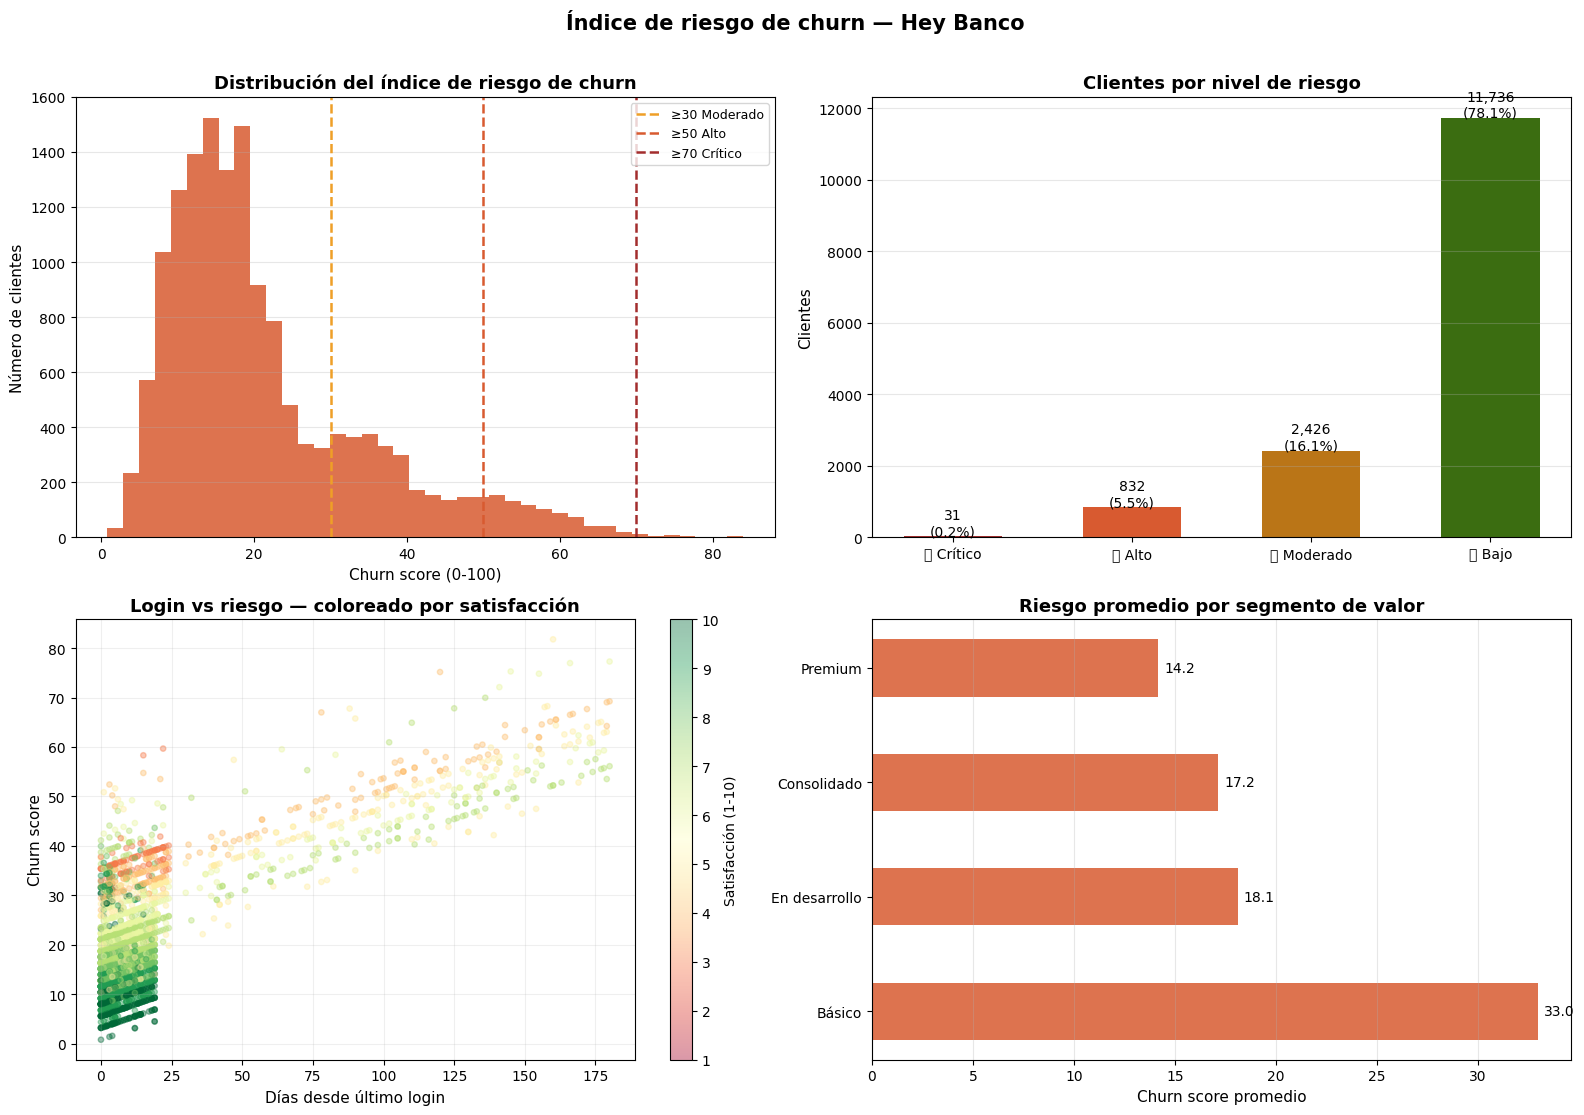


── Resumen por nivel de riesgo ──
             clientes  score_prom  login_prom  satisfaccion_prom  ingreso_prom
nivel_churn                                                                   
🔴 Crítico          31        75.3       138.1                5.1       18903.2
🟠 Alto            832        56.8       129.5                5.1       19485.6
🟡 Moderado       2426        37.8        36.9                5.3       20176.8
🟢 Bajo          11736        15.5         6.8                8.1       32541.2

── Top 10 clientes críticos para intervención inmediata ──
  user_id  churn_score  dias_desde_ultimo_login  satisfaccion_1_10  ingreso_mensual_mxn
USR-10455    83.978571                      153                4.0                33500
USR-04930    82.673810                      177                5.0                33500
USR-02602    82.295238                      132                4.0                32000
USR-06347    81.768254                      160                5.0             

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# ── Construcción del score de churn (0-100) ──────────────────────────────────
# Cada componente se normaliza a [0,1] y se pondera

df_churn = df.copy()

# 1. Días sin login → más días = más riesgo (directo)
scaler01 = MinMaxScaler()
df_churn['r_login'] = scaler01.fit_transform(
    df_churn[['dias_desde_ultimo_login']]
)

# 2. Satisfacción → satisfacción baja = más riesgo (invertido)
df_churn['r_satisfaccion'] = 1 - scaler01.fit_transform(
    df_churn[['satisfaccion_1_10']].fillna(df['satisfaccion_1_10'].median())
)

# 3. Patrón de uso atípico → True = riesgo
df_churn['r_atipico'] = df_churn['patron_uso_atipico'].astype(float)

# 4. Canal de apertura → usuarios de sucursal tienen mayor churn digital
riesgo_canal = {
    'app':      0.1,
    'web':      0.25,
    'sucursal': 0.65,
    'telefono': 0.50,
}
df_churn['r_canal'] = df_churn['canal_apertura'].str.lower().map(riesgo_canal).fillna(0.4)

# 5. Pocos productos = menor stickiness
df_churn['r_productos'] = 1 - scaler01.fit_transform(
    df_churn[['num_productos_activos']]
)

# ── Score final ponderado ────────────────────────────────────────────────────
pesos = {
    'r_login':       0.35,   # factor más fuerte
    'r_satisfaccion': 0.25,
    'r_atipico':     0.20,
    'r_productos':   0.12,
    'r_canal':       0.08,
}

df['churn_score'] = sum(
    df_churn[col] * peso for col, peso in pesos.items()
) * 100  # escalar a 0-100

# Segmentar en niveles de riesgo
def nivel_riesgo(score):
    if score >= 70: return '🔴 Crítico'
    if score >= 50: return '🟠 Alto'
    if score >= 30: return '🟡 Moderado'
    return '🟢 Bajo'

df['nivel_churn'] = df['churn_score'].apply(nivel_riesgo)

# ── Visualizaciones ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Distribución del score
axes[0, 0].hist(df['churn_score'], bins=40, color='#D85A30',
                edgecolor='none', alpha=0.85)
for umbral, color, label in [(30, '#EF9F27', 'Moderado'),
                               (50, '#D85A30', 'Alto'),
                               (70, '#A32D2D', 'Crítico')]:
    axes[0, 0].axvline(umbral, color=color, linewidth=1.8,
                       linestyle='--', label=f'≥{umbral} {label}')
axes[0, 0].set_xlabel('Churn score (0-100)', fontsize=11)
axes[0, 0].set_ylabel('Número de clientes', fontsize=11)
axes[0, 0].set_title('Distribución del índice de riesgo de churn', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Conteo por nivel de riesgo
orden_nivel = ['🔴 Crítico', '🟠 Alto', '🟡 Moderado', '🟢 Bajo']
conteo_nivel = df['nivel_churn'].value_counts().reindex(
    [n for n in orden_nivel if n in df['nivel_churn'].values]
)
colores_nivel = ['#A32D2D', '#D85A30', '#BA7517', '#3B6D11']
bars = axes[0, 1].bar(conteo_nivel.index, conteo_nivel.values,
                       color=colores_nivel[:len(conteo_nivel)],
                       edgecolor='none', width=0.55)
axes[0, 1].set_ylabel('Clientes', fontsize=11)
axes[0, 1].set_title('Clientes por nivel de riesgo', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, conteo_nivel.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val + 30,
                    f'{val:,}\n({val/len(df)*100:.1f}%)',
                    ha='center', fontsize=10)

# 3. Churn score vs días sin login (scatter)
sample = df.sample(min(3000, len(df)), random_state=42)
scatter = axes[1, 0].scatter(
    sample['dias_desde_ultimo_login'], sample['churn_score'],
    c=sample['satisfaccion_1_10'].fillna(5),
    cmap='RdYlGn', alpha=0.4, s=15, vmin=1, vmax=10
)
plt.colorbar(scatter, ax=axes[1, 0], label='Satisfacción (1-10)')
axes[1, 0].set_xlabel('Días desde último login', fontsize=11)
axes[1, 0].set_ylabel('Churn score', fontsize=11)
axes[1, 0].set_title('Login vs riesgo — coloreado por satisfacción', fontsize=13, fontweight='bold')
axes[1, 0].grid(alpha=0.2)

# 4. Score promedio por segmento de valor
if 'segmento_valor_label' in df.columns:
    churn_seg = df.groupby('segmento_valor_label')['churn_score'].mean().sort_values(ascending=False)
    axes[1, 1].barh(churn_seg.index, churn_seg.values,
                    color='#D85A30', edgecolor='none', height=0.5, alpha=0.85)
    axes[1, 1].set_xlabel('Churn score promedio', fontsize=11)
    axes[1, 1].set_title('Riesgo promedio por segmento de valor', fontsize=13, fontweight='bold')
    axes[1, 1].grid(axis='x', alpha=0.3)
    for i, (idx, val) in enumerate(churn_seg.items()):
        axes[1, 1].text(val + 0.3, i, f'{val:.1f}', va='center', fontsize=10)

plt.suptitle('Índice de riesgo de churn — Hey Banco', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Resumen ejecutivo ────────────────────────────────────────────────────────
print("\n── Resumen por nivel de riesgo ──")
resumen_churn = df.groupby('nivel_churn').agg(
    clientes=('user_id', 'count'),
    score_prom=('churn_score', 'mean'),
    login_prom=('dias_desde_ultimo_login', 'mean'),
    satisfaccion_prom=('satisfaccion_1_10', 'mean'),
    ingreso_prom=('ingreso_mensual_mxn', 'mean'),
).round(1)
print(resumen_churn.to_string())

# ── Lista de acción para el chatbot ─────────────────────────────────────────
criticos = df[df['nivel_churn'] == '🔴 Crítico'].sort_values('churn_score', ascending=False)
print(f"\n── Top 10 clientes críticos para intervención inmediata ──")
print(criticos[['user_id', 'churn_score', 'dias_desde_ultimo_login',
                'satisfaccion_1_10', 'ingreso_mensual_mxn']].head(10).to_string(index=False))